## Trying the ensemble version of PTDAMH

In [3]:
import os
from time import time
import pickle
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
from functools import partial
from fastgb import fastgb
from globalfit.gb.generator import GBGenerator, fastgb_buffersize, FastGBExt
from globalfit.gb.block import GBBlock
from globalfit.gb.likelihood import GBLogLik
from globalfit.gb.likelihood_jax import GBLogLikJax
from globalfit.noise.generator import NoiseGenerator
from globalfit.gb.tools import XYZ2AET
from lisaorbits import EqualArmlengthOrbits

# from eryn.ensemble import EnsembleSampler
# from eryn.state import State
# from eryn.prior import ProbDistContainer, uniform_dist
# from eryn.utils import TransformContainer
# from eryn.moves import GaussianMove, StretchMove, CombineMove, MHMove
# from eryn.utils.utility import groups_from_inds

import corner

from ptdamh import runner as my_mcmc
from ptdamh import proposals as Proposals
from ptdamh import ensemble_runner as ensemble_mcmc


import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
jax.config.update("jax_enable_x64", True)
GF_REPO = os.path.realpath("/Users/stas/Projects/LISA/GlobalFit/global-fit/")

Tobs = 10485760.0
dt = 5.0
bsize = 64

In [5]:
np.random.seed(15)  # fixing the noise 

_noise_file = os.path.join(GF_REPO, 'auxfiles', 'noise_pars.h5')
_gbfile = os.path.join(GF_REPO, 'auxfiles', 'gb_true.h5')

_gbcat = GBGenerator.load_catalog(_gbfile)

gb_fband = [6.216e-3, 6.219e-3]
duration = [0, 10485760.0]
_sel = (_gbcat['Frequency'] > gb_fband[0]) & (_gbcat['Frequency'] < gb_fband[1])
_list = np.where(_sel)[0]

cfg = {
    "dt":dt,
    "gb_fband": gb_fband, 
    "AET": True,
    "ignore_T_channel": True,
    "domain": 'Frequency',
    "duration": duration, 
    "inputs": [
        {"add": [{"name":"cat", "generator": GBGenerator, "list": _list}], "file": _gbfile}, 
        {"add": [{"name":"cat", "generator": NoiseGenerator}], "file": _noise_file},
    ],
    "noise_params": _noise_file
} 
block = GBBlock(config=cfg)
block.load_tdi()
block.load_noise()

print (_gbcat[_list])

[(2.14104362e-23, 0.00621747, 3.08540766e-16,  0.19122362, 4.78383106, 1.44883313, 3.24941449, 3.90238858, 0., 0., 0., 0., 0., 0., 0., 0.,  7.47269928, 0., '', 0, 0.)
 (3.50476905e-23, 0.00621856, 1.31240183e-15, -0.16938328, 4.60813132, 1.79614242, 3.5511628 , 5.81270134, 0., 0., 0., 0., 0., 0., 0., 0., 13.37559459, 0., '', 0, 0.)
 (2.45939760e-23, 0.0062182 , 5.56699233e-16, -1.08865091, 3.03280483, 1.62098072, 1.30826979, 3.55278411, 0., 0., 0., 0., 0., 0., 0., 0.,  8.28745113, 0., '', 0, 0.)]


In [6]:
def _gbll_inst(cls, nsrcs, bsize, unroll_srcs=None, unroll_tdi=None):
    return cls(
        block.tdi,
        block.noise,
        block.fmin,
        block.fmax,
        smax=nsrcs,
        fgb_ext=bsize,
        unroll_srcs=unroll_srcs,
        unroll_tdi=unroll_tdi
    )

Nsrc=3
Npar_src = 8
dim = Nsrc * Npar_src
bsize = 64

fold_idx = (4, 6, 7, 4+Npar_src, 6+Npar_src, 7+Npar_src, 4+2*Npar_src, 6+2*Npar_src, 7+2*Npar_src)

_gbll = _gbll_inst(GBLogLik, Nsrc, bsize).loglik
jllkwargs = {}
_jgbll = jax.vmap(jax.jit(_gbll_inst(GBLogLikJax, Nsrc, bsize, **jllkwargs).loglik))

GB2_loglik = jax.jit(_gbll_inst(GBLogLikJax, 2, bsize, **jllkwargs).loglik)
GB3_loglik = jax.jit(_gbll_inst(GBLogLikJax, 3, bsize, **jllkwargs).loglik)


_srcHC245 = _gbll_inst(GBLogLik, 3, bsize).ldc_to_pars(_gbcat[_list], dicts=True)
print (_srcHC245)
_srcHC24 = _srcHC245[:2*Npar_src] 

print ("make sure we fixed the noise", GB3_loglik(_srcHC245))
# make sure we fixed the noise -188.01290930804637

[0.33265638 0.4898206  0.5084293  0.59503018 0.76137036 0.56083053
 0.65540519 0.08676368 0.38616485 0.85278449 0.53585466 0.41571276
 0.73340688 0.38827814 0.05549038 0.29474992 0.34770719 0.7330147
 0.51520896 0.05699891 0.48268588 0.47491833 0.98187836 0.64900794]
make sure we fixed the noise -203.45983125330835


In [7]:
from jax import lax

# print(initial_thetas.shape)
# print (jax.vmap(GB3_loglik)(initial_thetas))


def make_nonperiodic_mask(D: int, fold_idx=()):
    """mask[d]=True iff dim d is box-constrained (non-periodic)."""
    m = jnp.ones((D,), dtype=bool)
    if len(fold_idx):
        m = m.at[jnp.asarray(fold_idx, dtype=int)].set(False)
    return m

def make_boxed_logprob(log_prob_fn_single, *, low=0.0, high=1.0,
                       check_mask: jnp.ndarray | None = None):
    """
    Wrap (D,) -> () function with a [low,high] box prior on dims where check_mask==True.
    Returns a new (D,) -> () that yields -inf outside the box, and
    uses lax.cond so the heavy log_prob is NOT evaluated when invalid.
    """
    low = jnp.asarray(low); high = jnp.asarray(high)

    def _one(theta: jnp.ndarray):
        theta = jnp.asarray(theta)
        if check_mask is None:
            inside_all = jnp.all((theta >= low) & (theta <= high))
        else:
            # Only enforce on masked dims; others ignored (e.g., periodic)
            in_dim = (theta >= low) & (theta <= high)
            inside_all = jnp.all(jnp.where(check_mask, in_dim, True))

        def _do():   return log_prob_fn_single(theta)
        def _bad():  return jnp.array(-jnp.inf, dtype=theta.dtype)

        return lax.cond(inside_all, _do, _bad)

    return _one


check_mask = make_nonperiodic_mask(dim, fold_idx)           # True == enforce [0,1]
boxed_log_prob = make_boxed_logprob(GB3_loglik,           # your original fn
                                    low=0.0, high=1.0,
                                    check_mask=check_mask)

C=  4 | real=   0.46 ms | per eval =0.11448540026322007 
C=  8 | real=   0.66 ms | per eval =0.08258750021923333 
C= 12 | real=   0.75 ms | per eval =0.06245346739888191 
C= 16 | real=   1.02 ms | per eval =0.06383802538039163 
C= 24 | real=   1.11 ms | per eval =0.04609410049548993 
C= 32 | real=   1.17 ms | per eval =0.036510156496660784 
C= 48 | real=   1.68 ms | per eval =0.03497118304949254 
C= 64 | real=   1.95 ms | per eval =0.03052291867788881 
C=128 | real=   3.63 ms | per eval =0.028388215650920756 


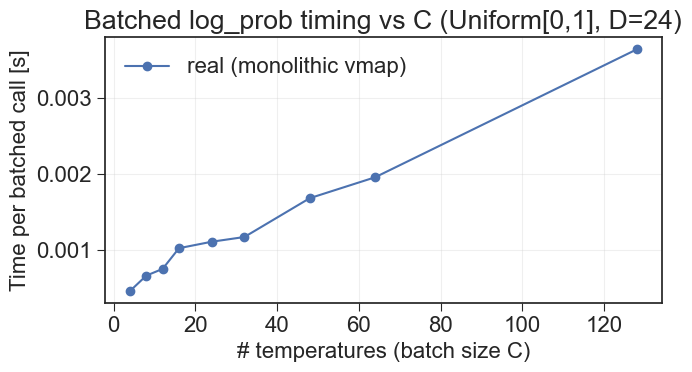

In [6]:
import time

# key = jax.random.PRNGKey(42)
key = jax.random.PRNGKey(24)

def make_batched(fn):
    return jax.jit(jax.vmap(fn))

# batched_real  = make_batched(GB3_loglik)
batched_real  = make_batched(boxed_log_prob)

Cs = [4, 8, 12, 16, 24, 32, 48, 64, 128]  # ladder sizes to test
warmup = 2
reps   = 5



def bench_one(batched_fn, C, key):
    # draw Uniform[0,1] parameters (C, D)
    key, sub = jax.random.split(key)
    x = jax.random.uniform(sub, shape=(C, dim), minval=0.0, maxval=1.0)
    # print (x.shape)
    # print (jax.vmap(GB3_loglik)(x))

    # warmup (compile + autotune)
    for _ in range(warmup):
        y = batched_fn(x)
        y.block_until_ready()

    # timed runs (vary inputs a bit so we don't re-hit caches identically)
    t0 = time.perf_counter()
    k = key
    for _ in range(reps):
        k, sub = jax.random.split(k)
        x = jax.random.uniform(sub, shape=(C, dim), minval=0.0, maxval=1.0)
        y = batched_fn(x)
        y.block_until_ready()  # IMPORTANT: sync with device
    t1 = time.perf_counter()
    return (t1 - t0) / reps

real_times = []
k = key
for C in Cs:
    tr  = bench_one(batched_real,  C, k)
    real_times.append(tr)
    print(f"C={C:>3d} | real={tr*1e3:7.2f} ms | per eval ={tr*1.e3/C} ")


plt.figure(figsize=(7,4))
plt.plot(Cs, real_times,        marker='o', label='real (monolithic vmap)')
plt.xlabel("# temperatures (batch size C)")
plt.ylabel("Time per batched call [s]")
plt.title("Batched log_prob timing vs C (Uniform[0,1], D=24)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
Num_temps = 30
Tmax = 10
Nsrc = 3
Npar_src = 8
dim = Nsrc * Npar_src
walkers = 16


cov = jnp.diag(jnp.full(dim, 0.01**2))

temps = my_mcmc.temperature_ladder(n_temps=Num_temps, T_min=1.0, T_max=Tmax, kind="geom", cold_dense=True, power=1.5)
print ('temperatures', temps)

# Create a starting point for each walker at each temperature by adding small noise
# to the true parameters.
# Shape will be (C, W, D) -> (Num_temps, walkers, dim)
key, subkey = jax.random.split(key)
noise = 1e-3 * jax.random.normal(subkey, shape=(Num_temps, walkers, dim))
initial_thetas = jnp.broadcast_to(_srcHC245, (Num_temps, walkers, dim)) + noise
initial_thetas = jnp.clip(initial_thetas, 0.0, 1.0) # ensure they are in [0,1]
print("Initial thetas shape:", initial_thetas.shape)

# Weights for the 5 proposal components: 
# 0: Student-t, 1: Eigen-line, 2: Full-cov, 3: Stretch, 4: DE
baseweight = (0.0, 0.5, 0.0, 0.2, 0.2)
weights = np.array([baseweight] * len(temps))


cfg = my_mcmc.AdaptConfig(
    m_epochs=300,       # number of adaptation epochs
    N_steps=500,      # number of steps per epoch
    # cov_mode = "all_states"
)


temperatures [1.        1.0148534 1.0425844 1.0796238 1.1251911 1.1792094 1.2419631
 1.3139853 1.3960142 1.4889795 1.594005  1.7124199 1.8457786 1.9958868
 2.164834  2.3550346 2.5692732 2.8107631 3.0832102 3.3908944 3.7387578
 4.132514  4.5787783 5.08521   5.6606936 6.315543  7.0617533 7.913274
 8.886365  9.999994 ]
Initial thetas shape: (30, 16, 24)


In [8]:
state, out = ensemble_mcmc.run_adaptive_pt_device_fast(
    key,
    initial_thetas=initial_thetas,     # (C,W,D)
    temperatures=temps,                    # (C,)
    log_prob_fn_single=boxed_log_prob,
    base_cov=cov,
    fold_idx=fold_idx,
    weights=weights,
    cfg=cfg,
    lik_chunk=64,
    product_space=False                # <— single model
)



Adaptive PT (ensemble):   3%|▎         | 10/300 [01:35<46:42,  9.66s/epoch]

Epoch 10/300 | swap_rate=0.823 | mean_acc=0.201


Adaptive PT (ensemble):   7%|▋         | 20/300 [03:09<44:18,  9.50s/epoch]

Epoch 20/300 | swap_rate=0.821 | mean_acc=0.154


Adaptive PT (ensemble):  10%|█         | 30/300 [04:46<44:08,  9.81s/epoch]

...

Epoch 280/300 | swap_rate=0.823 | mean_acc=0.107


Adaptive PT (ensemble):  97%|█████████▋| 290/300 [1:02:34<02:39, 15.91s/epoch]

Epoch 290/300 | swap_rate=0.821 | mean_acc=0.108


Adaptive PT (ensemble): 100%|██████████| 300/300 [1:05:14<00:00, 13.05s/epoch]


Epoch 300/300 | swap_rate=0.826 | mean_acc=0.100


In [18]:
slim = out["slim_per_epoch"]  # SlimInfo from the last epoch
print (len(slim))
# acc_cw  = slim.accept_rate_per_cw      # (C, W)
# acc_c   = slim.accept_rate_per_c       # (C,)
# swap_we = slim.swap_rate_per_w_edge    # (W, C-1)
# swap_e  = slim.swap_rate_per_edge      # (C-1,)

from ptdamh.utilities import SlimInfo

def combine_slim_over_epochs(slim_list, burnin_epochs=0):
    """
    Concatenate SlimInfo fields across epochs, skipping the first `burnin_epochs`.
    Assumes shapes (C, W) are the same across epochs.

    Returns: a *combined* SlimInfo with:
      - accepted_points[c][w]  = vstack of all epochs' accepted_points[c][w]
      - accepted_logprobs[c][w]= concat of all epochs' accepted_logprobs[c][w]
      - accept_rate_per_cw     = epoch-wise mean across remaining epochs
      - accept_rate_per_c      = mean over walkers of accept_rate_per_cw
      - swap_rate_per_w_edge   = epoch-wise mean across remaining epochs
      - swap_rate_per_edge     = mean over walkers of swap_rate_per_w_edge
    """
    slim_list = list(slim_list)[burnin_epochs:]
    if not slim_list:
        raise ValueError("No epochs left after burn-in.")

    # check shapes
    C = len(slim_list[0].accepted_points)
    W = len(slim_list[0].accepted_points[0])

    # init containers
    accepted_points = [[None for _ in range(W)] for _ in range(C)]
    accepted_logprobs = [[None for _ in range(W)] for _ in range(C)]

    # concat per (c,w)
    for c in range(C):
        for w in range(W):
            pts_list = []
            lp_list  = []
            for s in slim_list:
                arr_pts = s.accepted_points[c][w]
                if arr_pts is not None and arr_pts.size:
                    pts_list.append(np.asarray(arr_pts))
                arr_lp = s.accepted_logprobs[c][w]
                if arr_lp is not None and arr_lp.size:
                    lp_list.append(np.asarray(arr_lp))
            if pts_list:
                accepted_points[c][w] = np.vstack(pts_list)
            else:
                # keep a proper empty (D inferred if we saw any data elsewhere, otherwise 0)
                D = slim_list[0].accepted_points[c][w].shape[-1] if slim_list[0].accepted_points[c][w] is not None else 0
                accepted_points[c][w] = np.empty((0, D))
            if lp_list:
                accepted_logprobs[c][w] = np.concatenate(lp_list)
            else:
                accepted_logprobs[c][w] = np.empty((0,))

    # average rates over epochs (simple mean; good if epochs have same #steps)
    acc_cw_stack = np.stack([np.asarray(s.accept_rate_per_cw) for s in slim_list], axis=0)    # (E', C, W)
    swap_we_stack= np.stack([np.asarray(s.swap_rate_per_w_edge) for s in slim_list], axis=0)  # (E', W, C-1)

    accept_rate_per_cw = acc_cw_stack.mean(axis=0)                  # (C, W)
    accept_rate_per_c  = accept_rate_per_cw.mean(axis=1)            # (C,)
    swap_rate_per_w_edge = swap_we_stack.mean(axis=0)               # (W, C-1)
    swap_rate_per_edge   = swap_rate_per_w_edge.mean(axis=0)        # (C-1,)

    # Build a combined SlimInfo
    return SlimInfo(
        accepted_points=accepted_points,
        accepted_logprobs=accepted_logprobs,
        accept_rate_per_cw=accept_rate_per_cw,
        accept_rate_per_c=accept_rate_per_c,
        swap_rate_per_w_edge=swap_rate_per_w_edge,
        swap_rate_per_edge=swap_rate_per_edge,
    )

burnin_epochs = 50                    # e.g., skip first 5 epochs
slim_combined = combine_slim_over_epochs(slim, burnin_epochs=burnin_epochs)


300


In [19]:
# print("Accept per chain:", acc_c.round(3))
# print("Swap per edge   :", swap_e.round(3))

# counts = np.array([[len(slim.accepted_points[c][w]) 
#                     for w in range(acc_cw.shape[1])]
#                    for c in range(acc_cw.shape[0])])
# print("Accepted counts per (chain,walker):")
# print(counts)

def GR_from_accepted(points_list):
    """
    points_list: list of arrays [np.ndarray (N_i, D)], across walkers at fixed temp.
    Uses equal-length truncation to min(N_i).
    Returns: (D,) R-hat
    """
    lens = [p.shape[0] for p in points_list]
    m = len(points_list)
    if m < 2 or min(lens) < 2:
        return None  # not enough data

    L = min(lens)
    X = np.stack([p[:L] for p in points_list], axis=0)  # (m, L, D)
    chain_means = X.mean(axis=1)        # (m, D)
    grand_mean  = chain_means.mean(axis=0)  # (D,)

    # between- and within-chain variances
    B = L * ((chain_means - grand_mean)**2).sum(axis=0) / (m - 1)
    W = ((X - chain_means[:, None, :])**2).sum(axis=(0,1)) / (m * (L - 1))

    var_hat = ( (L - 1)/L ) * W + (1/L) * B
    rhat = np.sqrt(np.maximum(var_hat / (W + 1e-12), 0.0))
    return rhat
C, W = slim_combined.accept_rate_per_cw.shape
rhat_per_chain = []
for c in range(C):
    pts_list = [np.asarray(slim_combined.accepted_points[c][w])
                for w in range(W)
                if slim_combined.accepted_points[c][w].size > 0]
    rhat = GR_from_accepted(pts_list)
    rhat_per_chain.append(rhat)

print("R-hat per chain (first dim shown):",
      [None if r is None else float(r[0]) for r in rhat_per_chain])

R-hat per chain (first dim shown): [1.0223189359237288, 1.0224757657758297, 1.020441851153287, 1.021411375933343, 1.0173360556967688, 1.0208395976457807, 1.018722339663452, 1.0225027296337728, 1.0162476153796005, 1.0155168808571429, 1.0115325186561155, 1.0069197099953395, 1.009972898175244, 1.0161719861245422, 1.0295803562982615, 1.033246810304267, 1.032998218705079, 1.0317259384812754, 1.0287218291690312, 1.025931978781457, 1.021978988599999, 1.0178140393595676, 1.0175712535312311, 1.0177422144381745, 1.02019334964968, 1.0155478991424314, 1.0103960356486883, 1.009754699622479, 1.0075033421469002, 1.005703623932192]


(98647, 24)


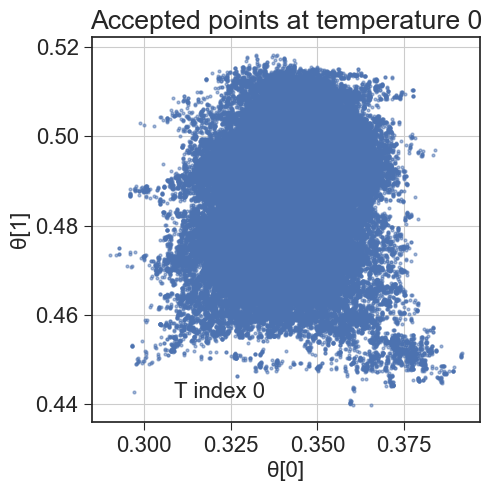

In [20]:
def plot_accepted_points(slim, c0, dims=(0,1)):
    """
    slim : SlimInfo from your output
    c0   : int, temperature index
    dims : tuple(int,int), which parameter dims to plot
    """
    pts = [np.asarray(slim.accepted_points[c0][w]) 
           for w in range(len(slim.accepted_points[c0]))]
    pts = [p for p in pts if len(p)]  # drop empties
    if not pts:
        print(f"No accepted points for chain {c0}")
        return
    pts_all = np.vstack(pts)  # (N, D)

    d1, d2 = dims
    plt.figure(figsize=(5,5))
    plt.scatter(pts_all[:, d1], pts_all[:, d2], 
                s=4, alpha=0.5, label=f"T index {c0}")
    plt.xlabel(f"θ[{d1}]")
    plt.ylabel(f"θ[{d2}]")
    plt.legend()
    plt.title(f"Accepted points at temperature {c0}")
    plt.show()

# def plot_accepted_points(slim_combined, c0, dims=(0,1), figsize=(6,6)):
#     """
#     slim_combined : SlimInfo returned by combine_slim_over_epochs
#     c0            : temperature index
#     dims          : which parameter dims to plot
#     """
#     pts = [np.asarray(slim_combined.accepted_points[c0][w]) 
#            for w in range(len(slim_combined.accepted_points[c0]))]
#     pts = [p for p in pts if p.size]  # drop empties
#     if not pts:
#         print(f"No accepted points for chain {c0}")
#         return
#     pts_all = np.vstack(pts)  # (N, D)

#     d1, d2 = dims
#     plt.figure(figsize=figsize)
#     plt.scatter(pts_all[:, d1], pts_all[:, d2], s=4, alpha=0.5, label=f"T index {c0}")
#     plt.xlabel(f"θ[{d1}]")
#     plt.ylabel(f"θ[{d2}]")
#     plt.legend()
#     plt.title(f"Accepted points at temperature {c0} (combined over epochs)")
#     plt.tight_layout()
#     plt.show()


def posterior_samples_from_walkers(slim, c, burnin_frac=0.5, thin=1):
    """
    Returns a single (N, D) array of accepted samples pooled across walkers
    for temperature index c, after burn-in and thinning.
    """
    pts_c = slim.accepted_points[c]           # list of length W; ragged arrays (N_acc_w, D)
    pooled = []
    for arr in pts_c:
        if arr.size == 0:
            continue
        n = len(arr)
        b0 = int(n * burnin_frac)
        keep = arr[b0::thin]
        if keep.size:
            pooled.append(keep)
    if not pooled:
        return np.empty((0, 0))
    return np.vstack(pooled)  

samples = posterior_samples_from_walkers(slim_combined, c=0, burnin_frac=0.1, thin=2)
print (samples.shape)
plot_accepted_points(slim_combined, c0=0, dims=(0,1)) 



In [21]:
def posterior_logprobs_from_walkers(slim, c, burnin_frac=0.5, thin=1):
    """
    Returns a single (N,) array of accepted log-probs pooled across walkers
    for temperature index c, after burn-in and thinning.
    """
    lp_c = slim.accepted_logprobs[c]   # list of length W; ragged arrays (N_acc_w,)
    pooled = []
    for arr in lp_c:
        if arr.size == 0:
            continue
        n = len(arr)
        b0 = int(n * burnin_frac)
        keep = arr[b0::thin]
        if keep.size:
            pooled.append(keep)
    if not pooled:
        return np.empty((0,))
    return np.concatenate(pooled)


def plot_accepted_logprob(
    slim,
    c0: int,
    *,
    per_walker: bool = False,
    burnin_frac: float = 0.5,
    thin: int = 1,
    kind: str = "trace",  # "trace" or "hist"
    bins: int = 40,
    alpha: float = 0.8,
    ms: int = 6,
    title: str | None = None,
):
    """
    Plot log-probability of accepted points at temperature index c0.
      - per_walker=False: pool all walkers and plot one series.
      - per_walker=True : plot one series per walker in different colors.
    """
    lp_c = slim.accepted_logprobs[c0]  # list length W

    plt.figure(figsize=(7.2, 4.8))

    if per_walker:
        for w, arr in enumerate(lp_c):
            if arr is None or arr.size == 0:
                continue
            n = len(arr)
            b0 = int(n * burnin_frac)
            series = arr[b0::thin]
            if series.size == 0:
                continue
            if kind == "trace":
                x = np.arange(series.size)
                plt.plot(x, series, marker='.', ms=ms, alpha=alpha, linestyle='-', label=f"walker {w}")
            elif kind == "hist":
                plt.hist(series, bins=bins, alpha=0.45, density=True, histtype='stepfilled', label=f"walker {w}")
        plt.legend(ncol=2, fontsize=9, frameon=False)

    else:
        pooled = posterior_logprobs_from_walkers(slim, c0, burnin_frac=burnin_frac, thin=thin)
        if pooled.size == 0:
            plt.text(0.5, 0.5, f"No accepted log-probs at temp c={c0}", ha='center', va='center')
            plt.axis('off')
            plt.show()
            return
        if kind == "trace":
            x = np.arange(pooled.size)
            plt.plot(x, pooled, marker='.', ms=ms, alpha=alpha, linestyle='-')
        elif kind == "hist":
            plt.hist(pooled, bins=bins, alpha=0.7, density=True, histtype='stepfilled')

    if kind == "trace":
        plt.xlabel("accepted index")
        plt.ylabel("log p(θ)")
    else:
        plt.xlabel("log p(θ)")
        plt.ylabel("density")

    t = title or f"Accepted log-prob @ temp c={c0}"
    t += " (per-walker)" if per_walker else " (combined)"
    plt.title(t)
    plt.tight_layout()
    plt.show()



def plot_logprob_temp_box(
    slim, c: int, *, burnin_frac=0.5, thin=1,
    title=None, show_points=True, jitter=0.08, ms=2, alpha=0.6
):
    """
    Box/violin-style summary per walker for temperature c.
    Uses posterior_logprobs_from_walkers for pooling.
    """
    # full pooled log-probs across walkers (burnin+thin applied)
    pooled = posterior_logprobs_from_walkers(slim, c, burnin_frac=burnin_frac, thin=thin)

    # also keep per-walker lists (with burnin+thin applied) for boxplot breakdown
    lp_c = slim.accepted_logprobs[c]   # list of length W
    data = []
    for arr in lp_c:
        if arr.size == 0:
            data.append(np.empty((0,)))
            continue
        n = len(arr)
        b0 = int(n * burnin_frac)
        keep = arr[b0::thin]
        data.append(keep)

    # check if any accepted
    if not any(arr.size > 0 for arr in data):
        plt.figure(figsize=(7, 3))
        plt.text(0.5, 0.5, f"No accepted points at temperature c={c}",
                 ha='center', va='center')
        plt.axis('off')
        plt.show()
        return

    plt.figure(figsize=(9, 4.5))
    plt.boxplot([d for d in data if d.size > 0], showfliers=False)

    if show_points:
        rng = np.random.default_rng()
        for i, arr in enumerate([d for d in data if d.size > 0], start=1):
            x = i + (rng.random(arr.size) - 0.5) * 2 * jitter
            plt.plot(x, arr, 'o', ms=ms, alpha=alpha, linestyle='None')

    plt.xlabel("walker (only walkers with at least one accept are shown)")
    plt.ylabel("log-probability")
    plt.title(title or f"Accepted log-probabilities @ temperature c={c}")
    plt.tight_layout()
    plt.show()

    return pooled





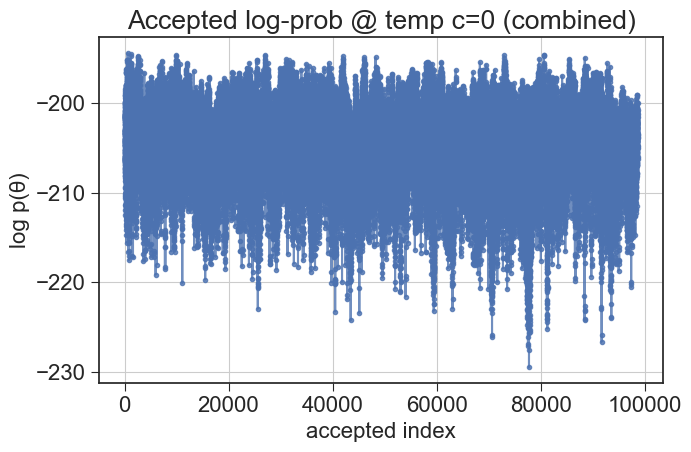

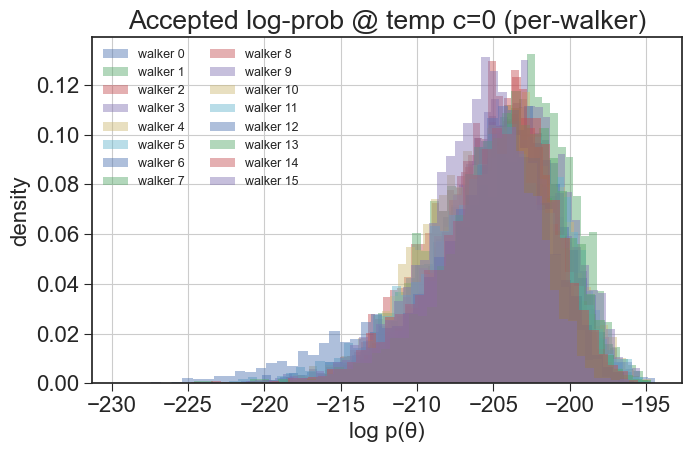

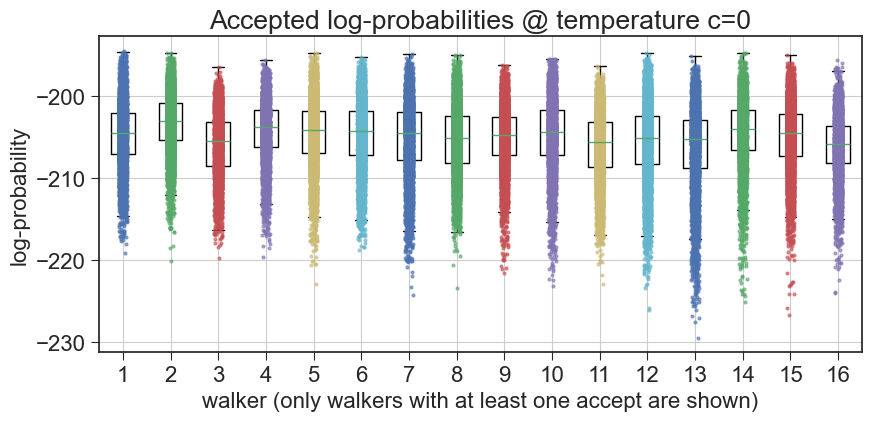

array([-201.8401941 , -203.09875425, -201.49360413, ..., -200.78978611,
       -199.95945112, -201.21206535])

In [22]:
# Pooled across walkers (trace plot):
plot_accepted_logprob(slim_combined, c0=0, per_walker=False, kind="trace", burnin_frac=0.1, thin=2)

# Per-walker colored histogram:
plot_accepted_logprob(slim_combined, c0=0, per_walker=True, kind="hist", bins=50, burnin_frac=0.1, thin=2)

## Box/violin plot per walker:
plot_logprob_temp_box(slim_combined, c=0, burnin_frac=0.1, thin=2)

In [14]:
def plot_swap_heatmap_per_walker_edge(slim, *, cmap='viridis'):
    H = np.asarray(slim.swap_rate_per_w_edge)  # (W, C-1)
    W, Cminus1 = H.shape

    # plt.figure(figsize=(4*Cminus1, 0.8*W + 6))   # enlarged
    plt.figure(figsize=(15,8))
    im = plt.imshow(H, aspect='auto', interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, label='Swap acceptance', shrink=0.8)
    plt.xlabel('Adjacent pair index (i ↔ i+1)')
    plt.ylabel('Walker')
    plt.title('Swap acceptance heatmap (per walker × pair)')
    plt.xticks(ticks=np.arange(Cminus1), labels=[f'{i}↔{i+1}' for i in range(Cminus1)])
    plt.tight_layout()
    plt.show()

def plot_swap_bar_per_edge(slim, *, ylines=(0.2, 0.4)):
    r = np.asarray(slim.swap_rate_per_edge)  # (C-1,)
    Cminus1 = r.size

    # plt.figure(figsize=(2*Cminus1, 6))   # enlarged
    plt.figure(figsize=(15,8))
    plt.bar(np.arange(Cminus1), r)
    for y in ylines:
        plt.axhline(y, ls='--', lw=1, color='grey')
    plt.xlabel('Adjacent pair (i ↔ i+1)')
    plt.ylabel('Swap acceptance rate')
    plt.ylim(0, 1)
    plt.title('Per-pair swap acceptance (overall across walkers)')
    plt.tight_layout()
    plt.show()


def print_acceptance_tables(slim):
    A = np.asarray(slim.accept_rate_per_cw)   # (C, W)
    C, W = A.shape
    print("Per-chain × walker acceptance (rows=chains, cols=walkers):")
    with np.printoptions(precision=3, suppress=True):
        print(A)
    print("\nPer-chain acceptance (walkers combined):")
    with np.printoptions(precision=3, suppress=True):
        print(np.asarray(slim.accept_rate_per_c))  # (C,)

def plot_accept_heatmap_per_chain_walker(slim, *, cmap='magma', dpi=160):
    A = np.asarray(slim.accept_rate_per_cw)  # (C, W)
    C, W = A.shape
    fig, ax = plt.subplots(figsize=(10,10), dpi=dpi)
    im = ax.imshow(A, aspect='auto', interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=ax, label='Acceptance rate', shrink=0.85)
    ax.set_xlabel('Walker')
    ax.set_ylabel('Chain (temperature index)')
    ax.set_title('Acceptance rate per chain × walker')
    ax.set_xticks(np.arange(W))
    ax.set_yticks(np.arange(C))
    fig.tight_layout()
    plt.show()

def plot_accept_bar_per_chain_combined(slim, *, dpi=160):
    acc_c = np.asarray(slim.accept_rate_per_c)  # (C,)
    C = acc_c.size
    fig, ax = plt.subplots(figsize=(15,6), dpi=dpi)
    ax.bar(np.arange(C), acc_c)
    ax.axhline(0.234, ls='--', lw=1, color='gray', label='RW-MH heuristic ~0.234')
    ax.set_xlabel('Chain (temperature index)')
    ax.set_ylabel('Acceptance rate (combined over walkers)')
    ax.set_ylim(0, 1)
    ax.set_title('Per-chain acceptance (walkers combined)')
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()

def plot_accept_distribution_per_chain(slim, *, dpi=160):
    """Boxplot across walkers for each chain (shows dispersion across walkers)."""
    A = np.asarray(slim.accept_rate_per_cw)  # (C, W)
    C, W = A.shape
    fig, ax = plt.subplots(figsize=(15,6), dpi=dpi)
    ax.boxplot([A[c] for c in range(C)], showfliers=False)
    ax.set_xlabel('Chain (temperature index)')
    ax.set_ylabel('Acceptance rate across walkers')
    ax.set_ylim(0, 1)
    ax.set_title('Walker-level acceptance dispersion per chain')
    fig.tight_layout()
    plt.show()


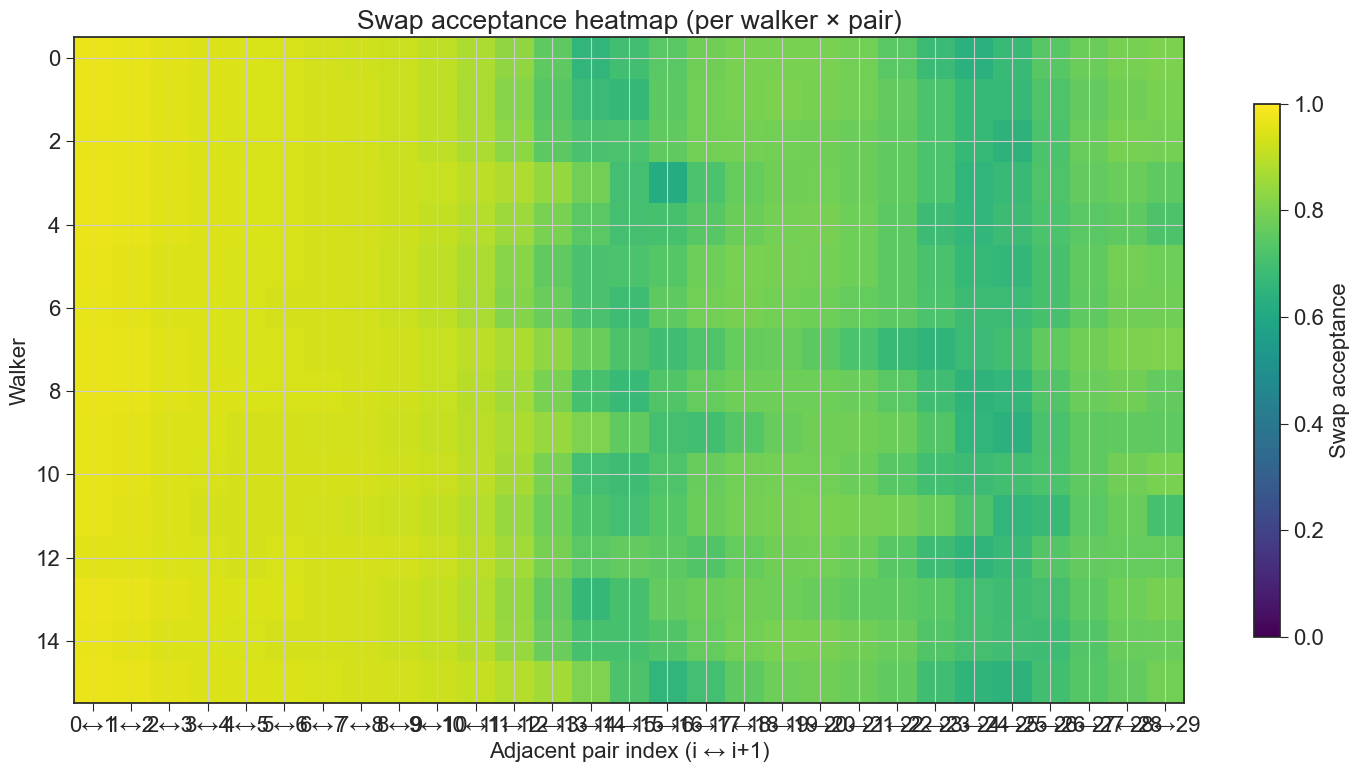

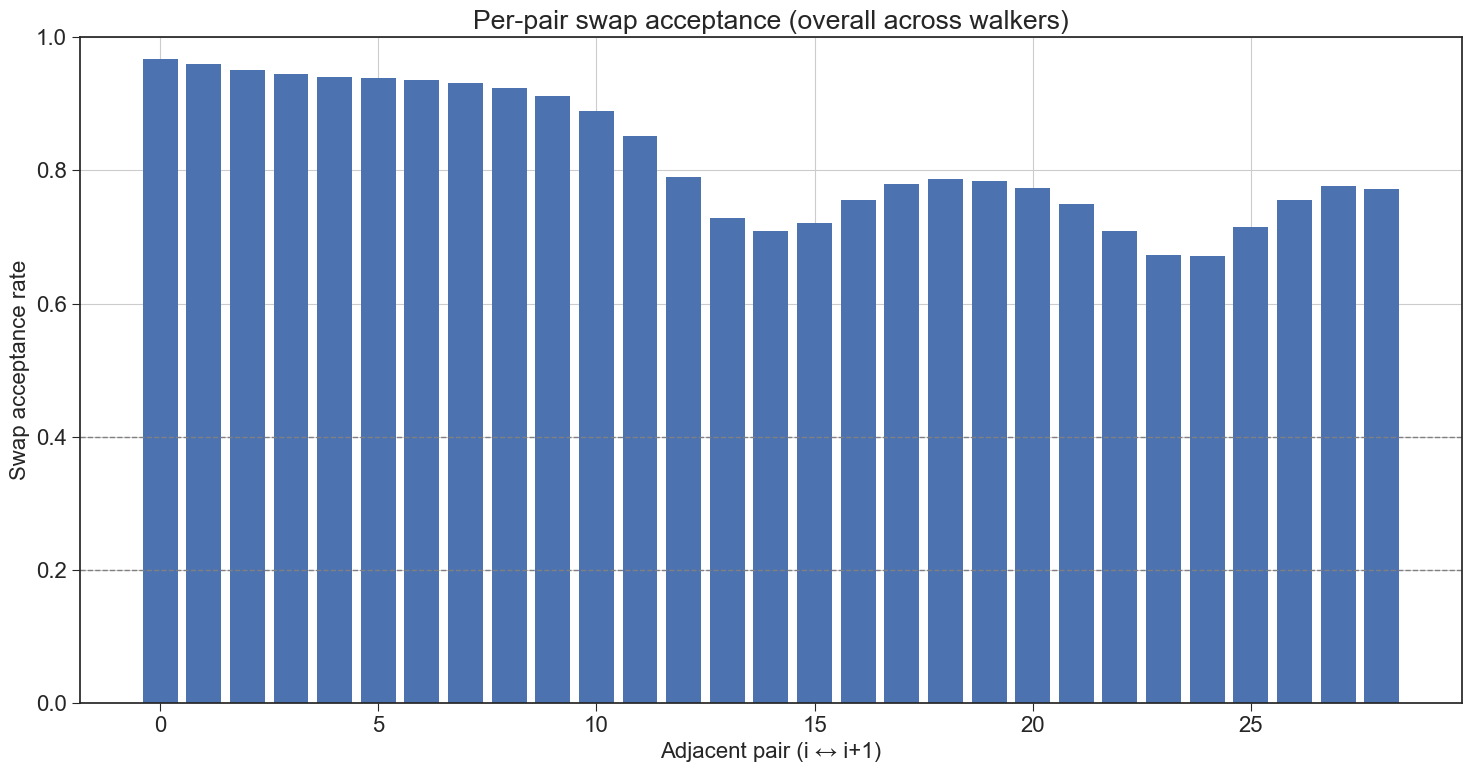

Per-chain × walker acceptance (rows=chains, cols=walkers):
[[0.113 0.118 0.111 0.109 0.12  0.11  0.118 0.111 0.111 0.113 0.115 0.118
  0.106 0.109 0.114 0.106]
 [0.112 0.113 0.112 0.114 0.121 0.114 0.113 0.116 0.113 0.122 0.114 0.121
  0.106 0.113 0.113 0.117]
 [0.12  0.118 0.118 0.115 0.119 0.113 0.12  0.117 0.119 0.117 0.104 0.126
  0.117 0.113 0.114 0.114]
 [0.109 0.11  0.12  0.114 0.116 0.116 0.118 0.109 0.115 0.115 0.113 0.118
  0.114 0.113 0.113 0.116]
 [0.114 0.118 0.118 0.117 0.116 0.109 0.116 0.118 0.115 0.119 0.118 0.116
  0.108 0.114 0.121 0.108]
 [0.114 0.111 0.123 0.117 0.114 0.116 0.124 0.116 0.12  0.11  0.117 0.119
  0.118 0.119 0.114 0.12 ]
 [0.116 0.117 0.117 0.112 0.117 0.113 0.112 0.12  0.117 0.117 0.121 0.118
  0.106 0.123 0.109 0.111]
 [0.129 0.12  0.128 0.121 0.12  0.116 0.121 0.12  0.116 0.121 0.131 0.116
  0.122 0.127 0.124 0.121]
 [0.114 0.116 0.122 0.118 0.126 0.122 0.123 0.119 0.118 0.123 0.124 0.12
  0.118 0.121 0.124 0.115]
 [0.113 0.11  0.122 0.12  0.121 0

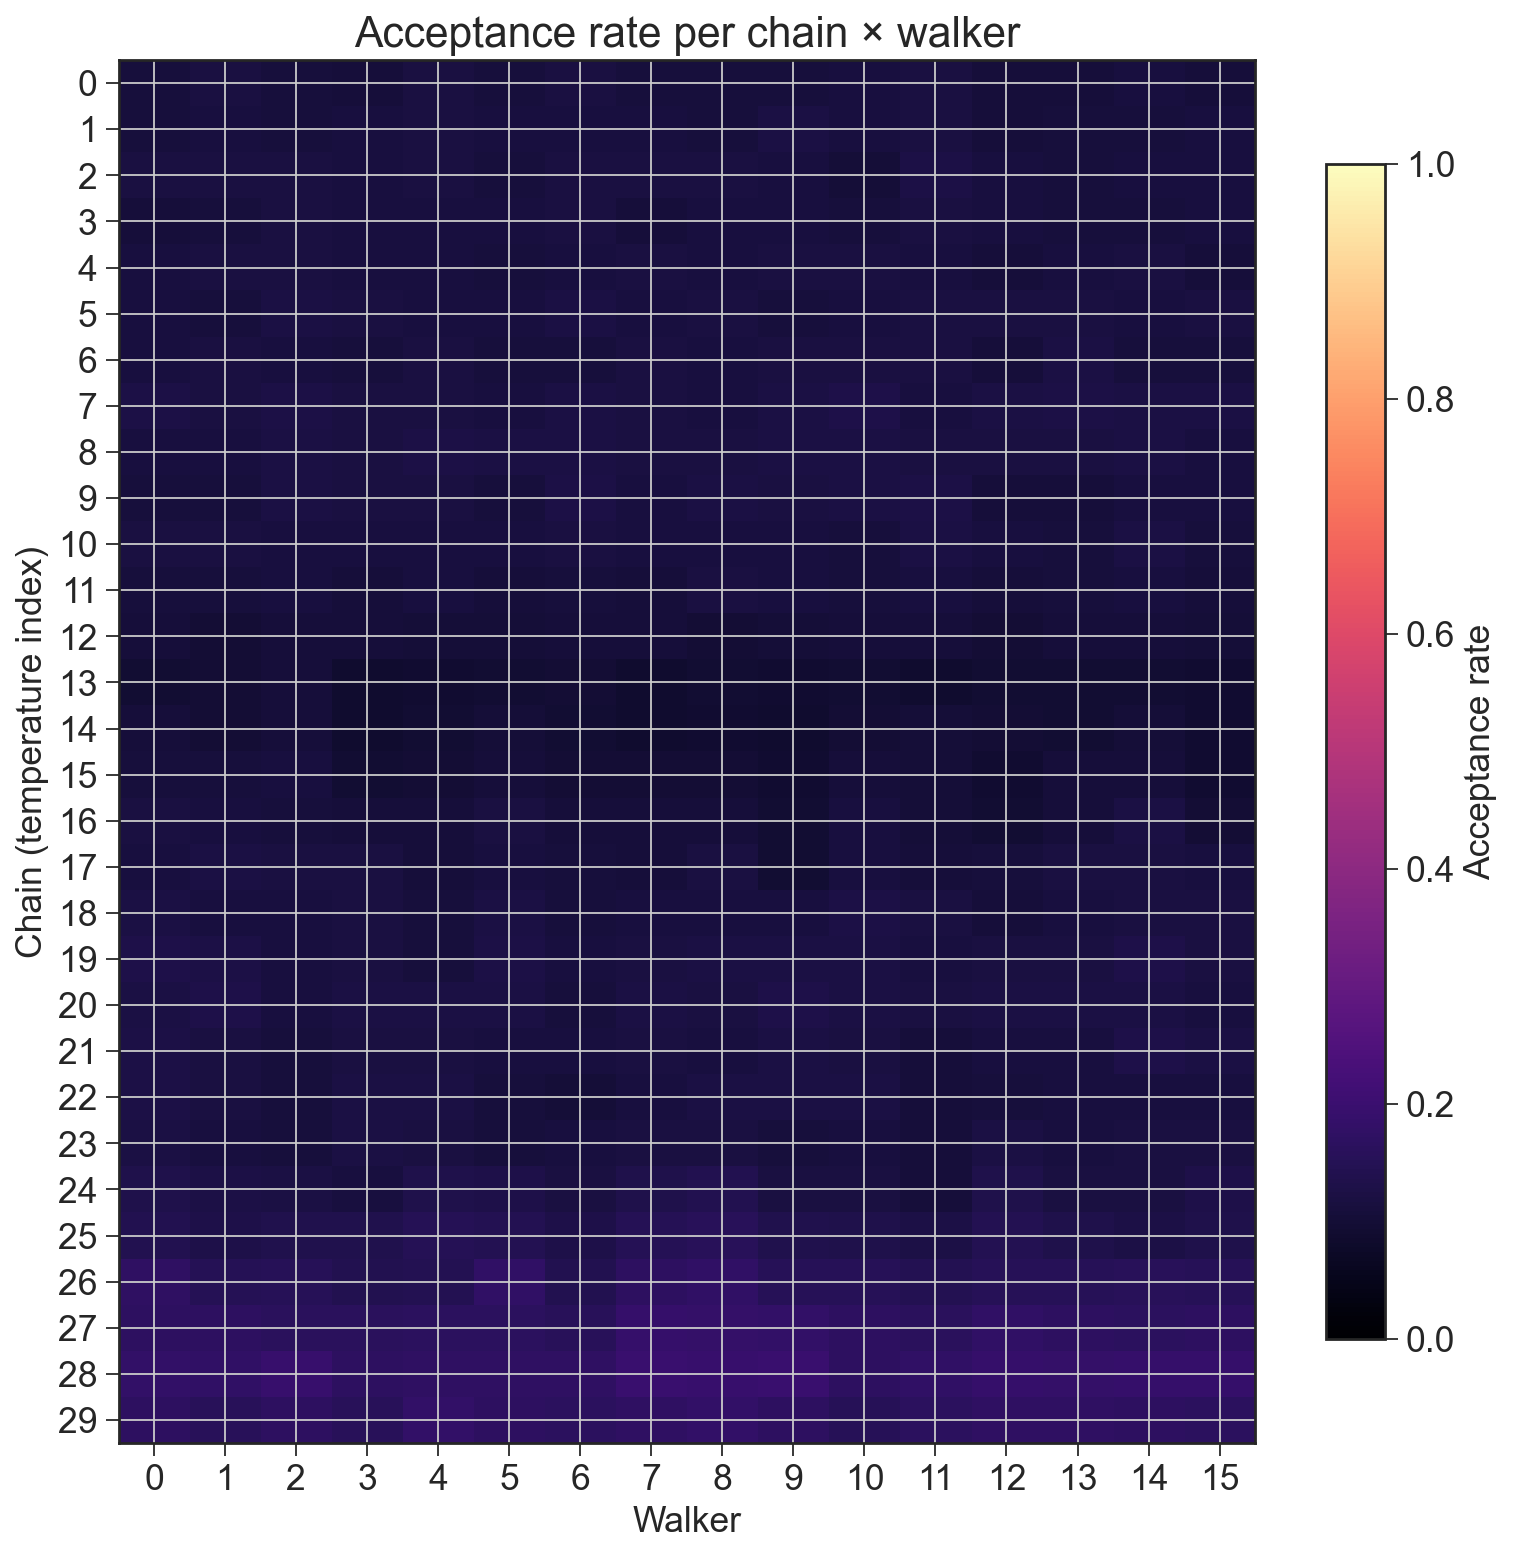

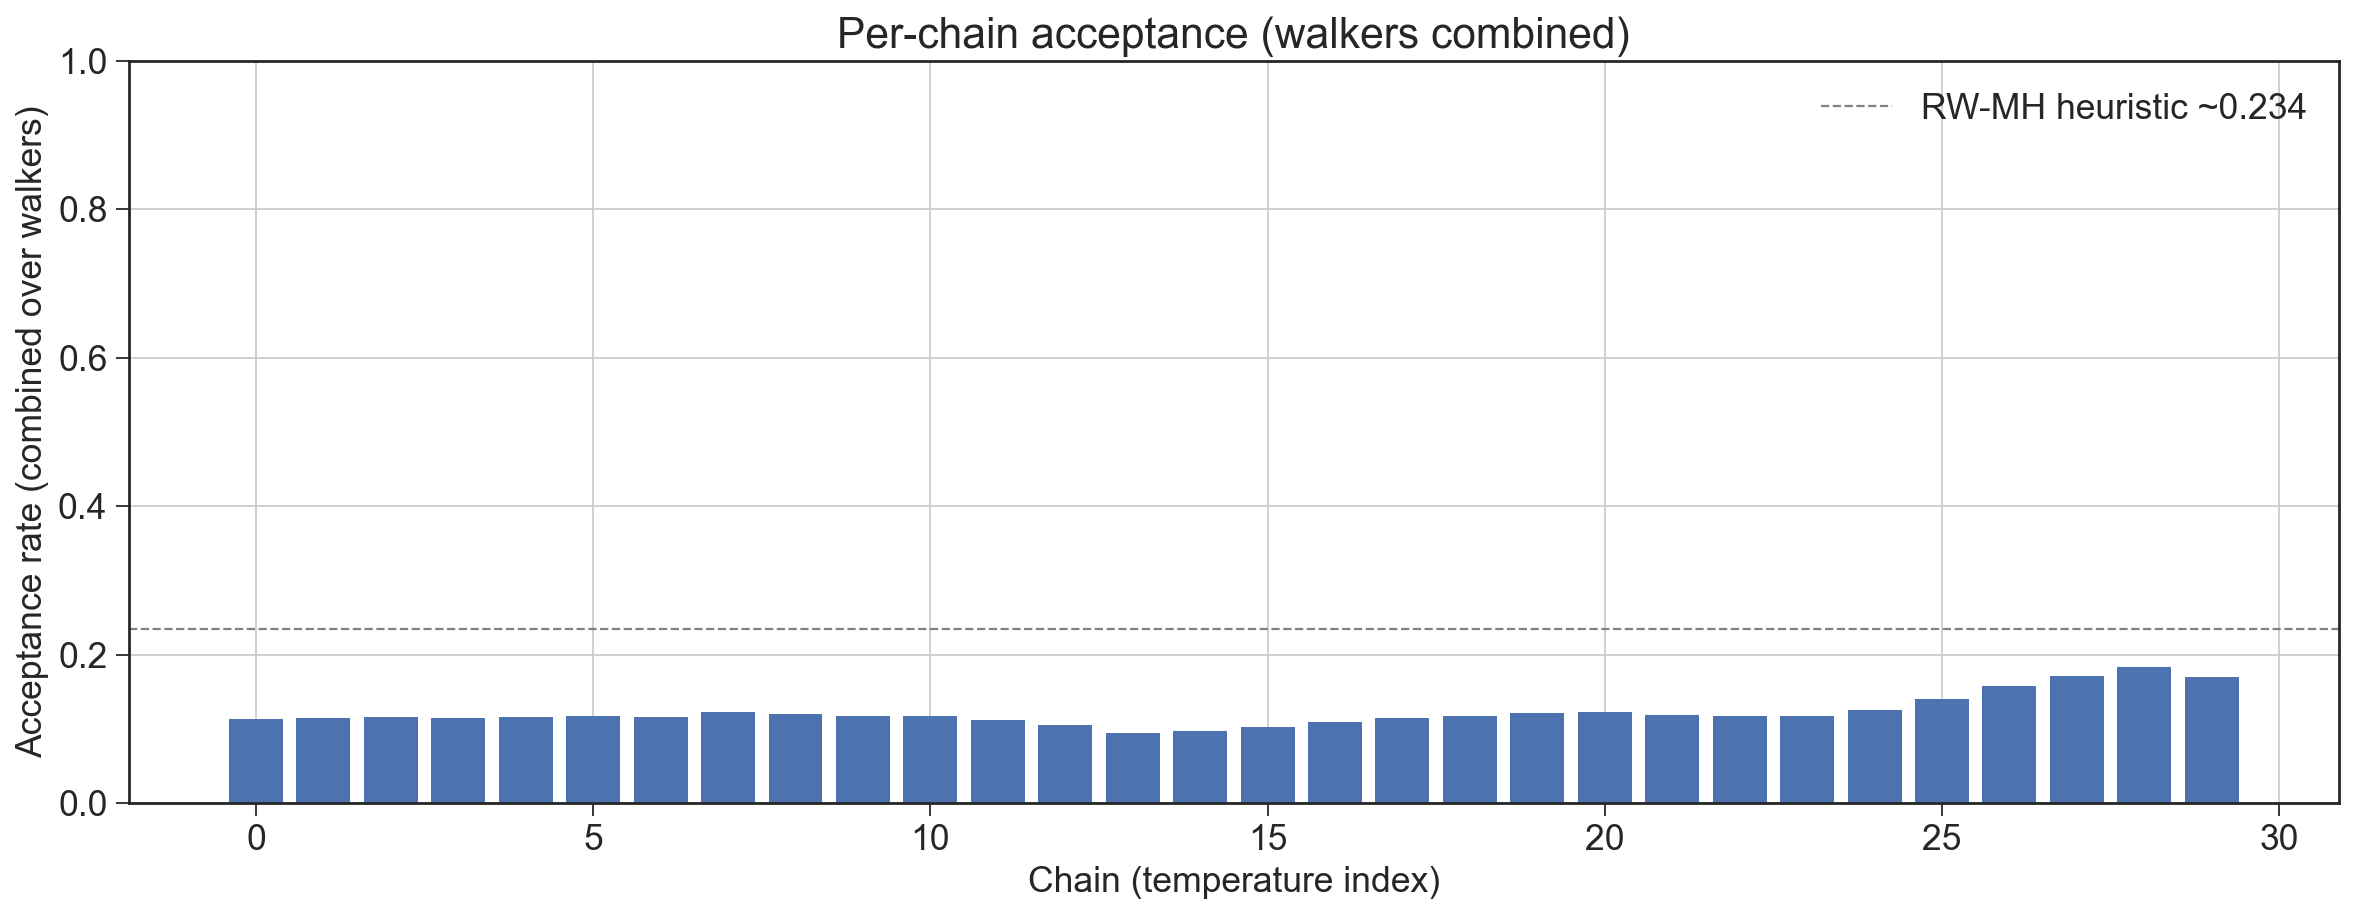

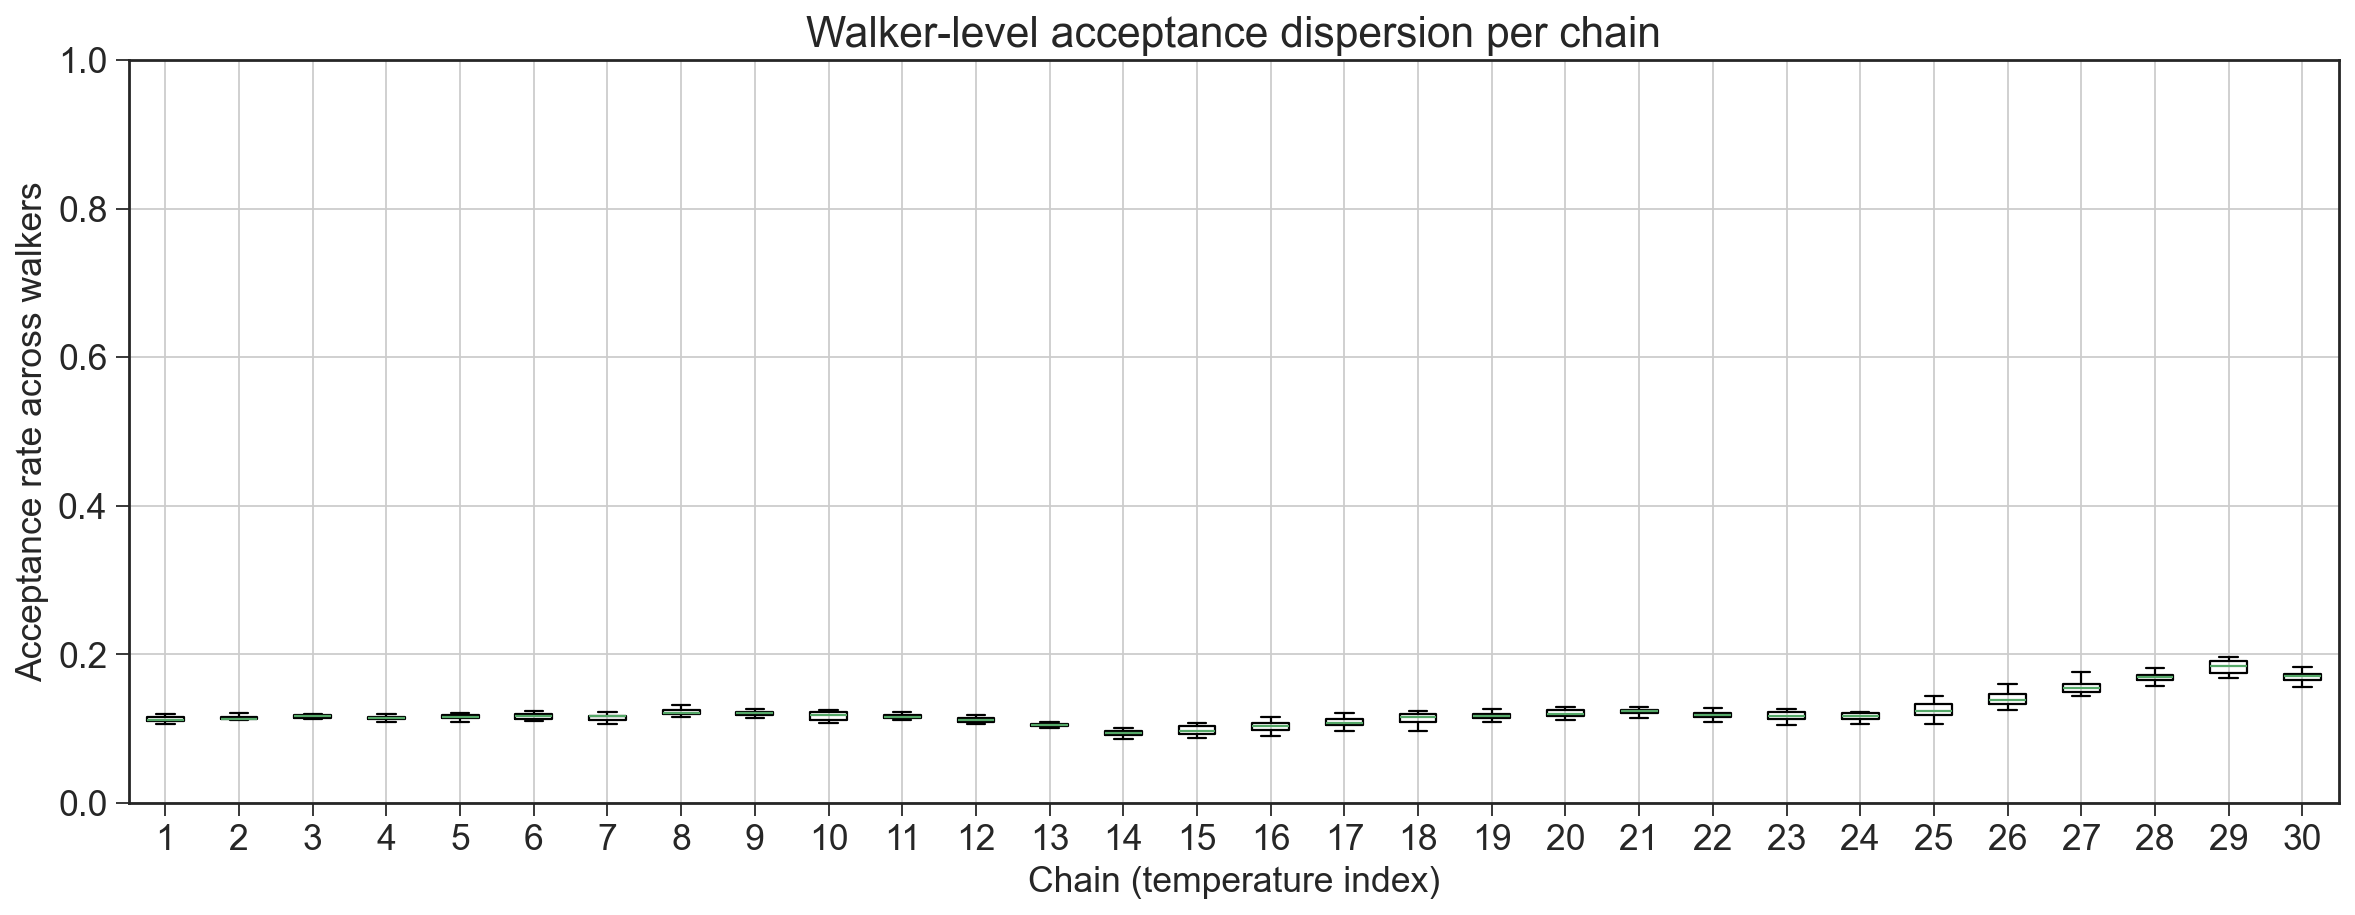

In [15]:
# --- Swap diagnostics ---
plot_swap_heatmap_per_walker_edge(slim_combined, cmap="viridis")   # heatmap per walker×pair
plot_swap_bar_per_edge(slim_combined)                             # bar per adjacent pair

# --- Acceptance diagnostics ---
print_acceptance_tables(slim_combined)

plot_accept_heatmap_per_chain_walker(slim_combined)         # chain × walker heatmap
plot_accept_bar_per_chain_combined(slim_combined)           # one bar per chain (all walkers pooled)
plot_accept_distribution_per_chain(slim_combined)           # boxplot: dispersion across walkers per chain

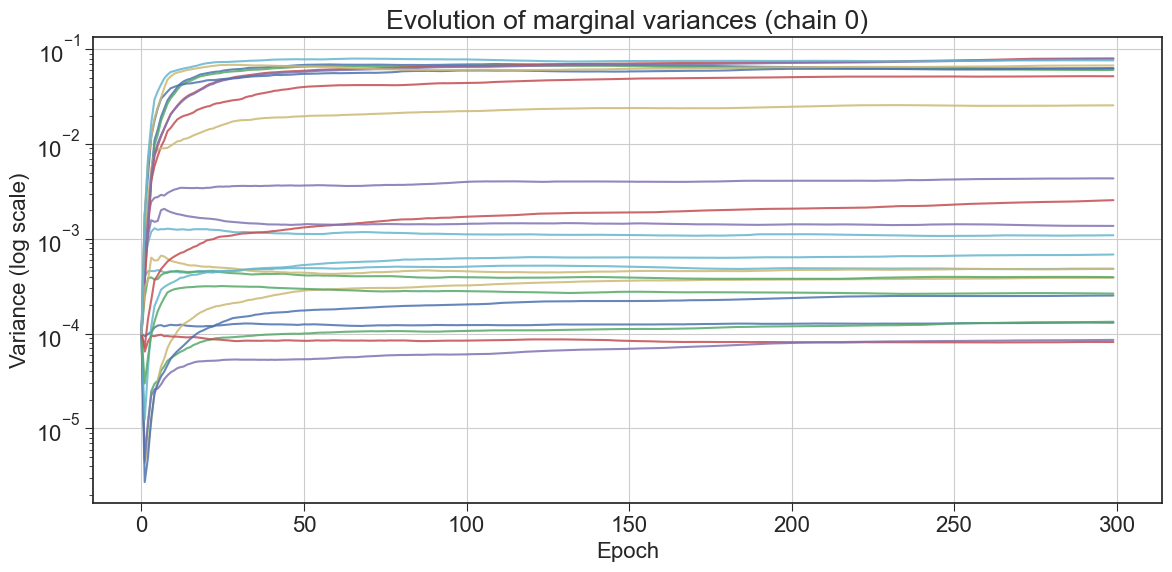

In [16]:
#   out = {
#         "slim_per_epoch": slim_per_epoch,                # list of SlimInfo / SlimInfoPS
#         "scales_per_epoch": np.stack(scales_per_epoch),  # (E, C)
#         "covs_per_epoch":   np.stack(covs_per_epoch),    # (E, C, D, D)
#         "swap_rate_per_epoch": np.array(swap_rate_epoch),
#         "accept_rate_per_epoch": np.stack(accept_rate_epoch),  # (E, C)
#     }

from IPython.display import clear_output, display
from matplotlib import gridspec
import seaborn as sns
import time


covs_over_time = out['covs_per_epoch']
E, C, D, _ = covs_over_time.shape
chain_id = 0 


# -------------------------
# Animated correlation heatmap every Nep epochs (fixed colorbar)
# -------------------------
Nep = 10            # <-- update cadence (e.g., every 10 epochs)
chain_id = 0        # which temperature/chain to visualize

fig = plt.figure(figsize=(9, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[20, 1], wspace=0.08)
ax = plt.subplot(gs[0])
cbar_ax = plt.subplot(gs[1])

# frames at multiples of Nep, plus ensure last epoch included
frames = list(range(0, E, max(1, Nep)))
if (E - 1) not in frames:
    frames.append(E - 1)

for i, e in enumerate(frames):
    Cmat = covs_over_time[e, chain_id]  # (D, D)
    ax.clear()

    # correlation with epsilon guard
    S = np.clip(np.diag(Cmat), 0.0, None)
    denom = np.sqrt(np.outer(S, S)) + 1e-12
    corr = Cmat / denom

    is_first = (i == 0)
    sns.heatmap(
        corr, vmin=-1, vmax=1, cmap="coolwarm",
        ax=ax, cbar=is_first, cbar_ax=cbar_ax if is_first else None,
        square=False
    )
    ax.set_title(f"Correlation (chain {chain_id}) @ epoch {e}")
    ax.set_xlabel("parameter")
    ax.set_ylabel("parameter")

    display(fig)
    clear_output(wait=True)
    time.sleep(0.25)  # adjust pause duration as you like

plt.close(fig)



# -------------------------
# 1) Variance evolution for one chain
# -------------------------
vars_evol = np.array([np.diag(covs_over_time[e, chain_id]) for e in range(E)])  # (E, D)

plt.figure(figsize=(12, 6))
for d in range(D):
    plt.semilogy(vars_evol[:, d], label=f"param {d}", alpha=0.85)
plt.xlabel("Epoch")
plt.ylabel("Variance (log scale)")
plt.title(f"Evolution of marginal variances (chain {chain_id})")
# plt.legend(ncol=4, fontsize=9)  # uncomment if you want legend
plt.tight_layout()
plt.show()


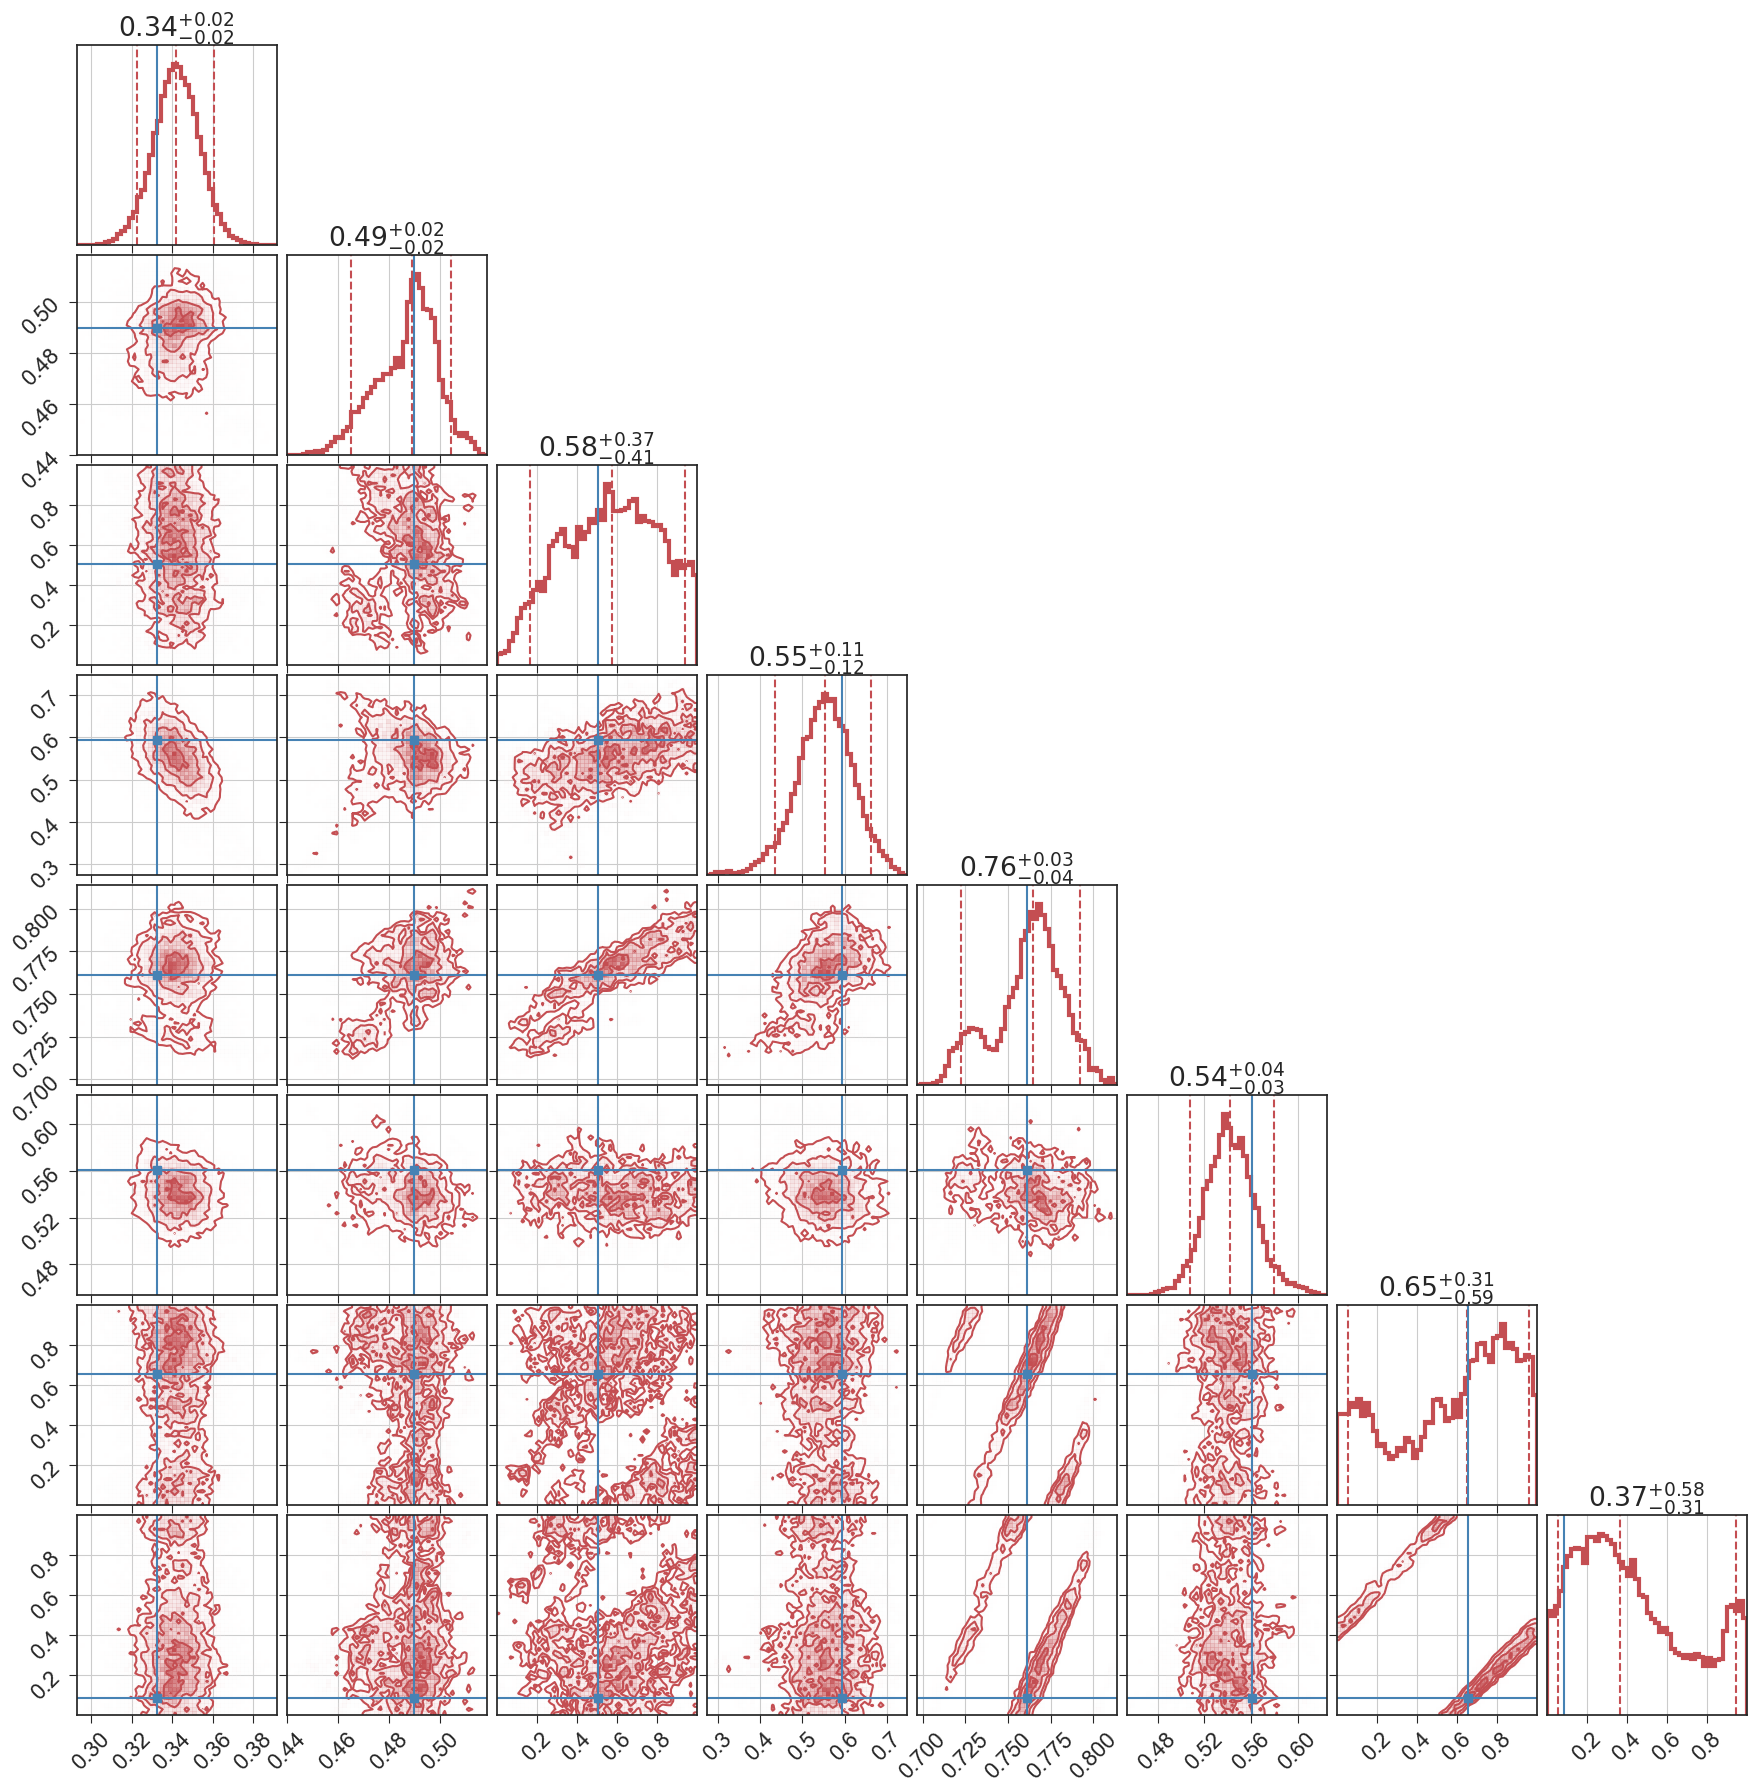

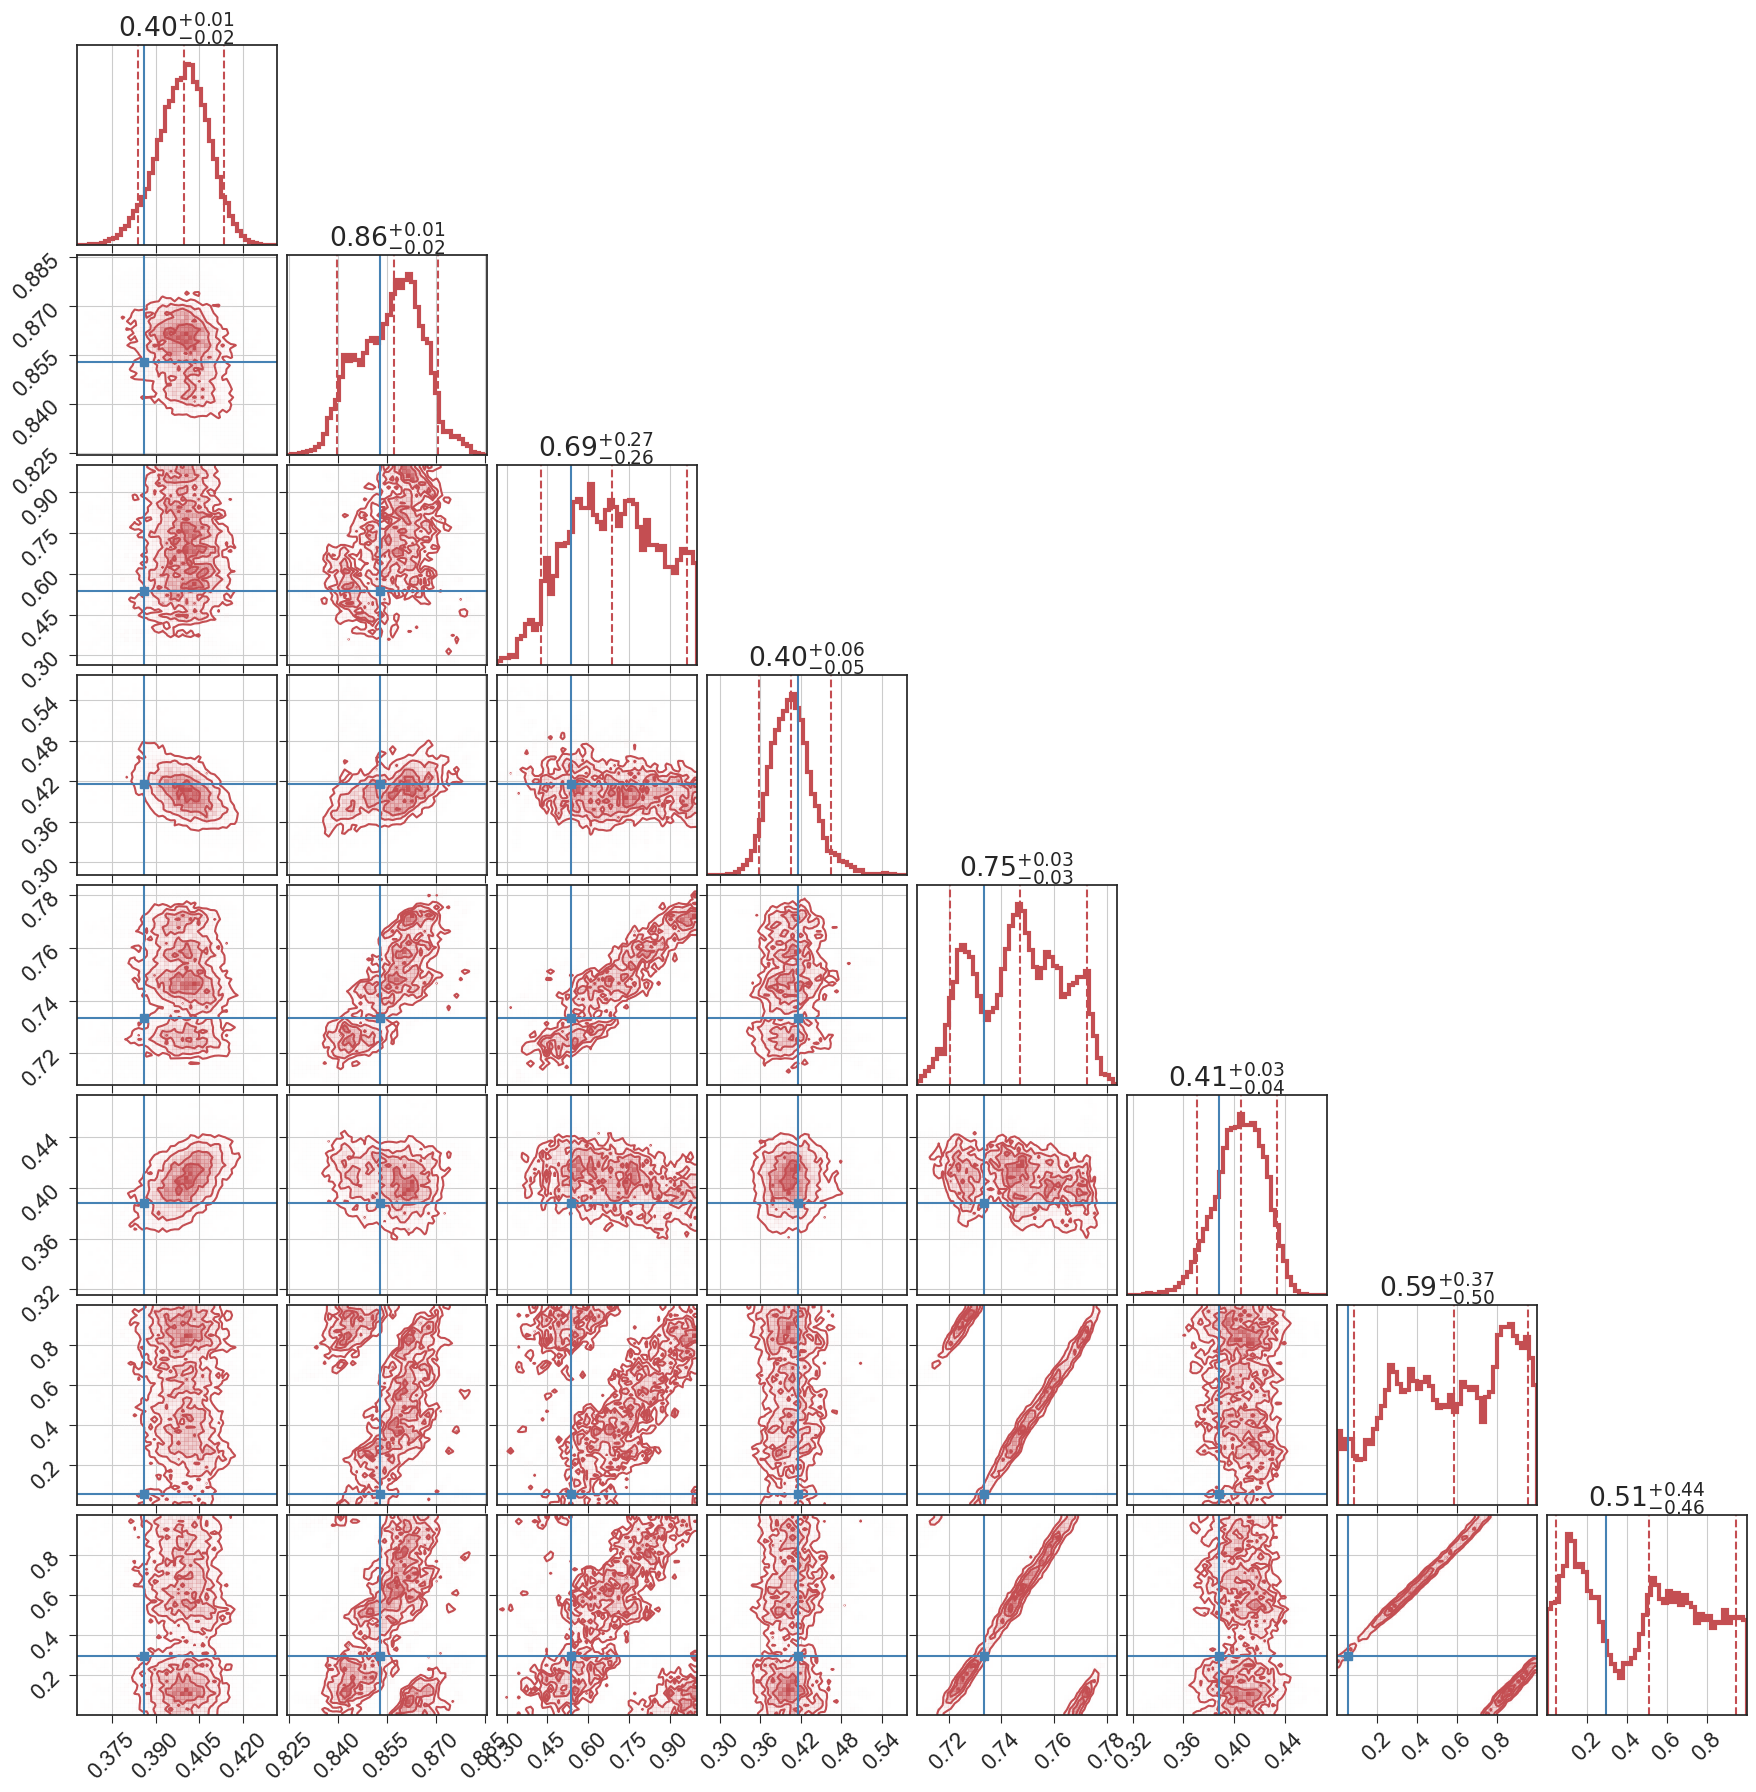

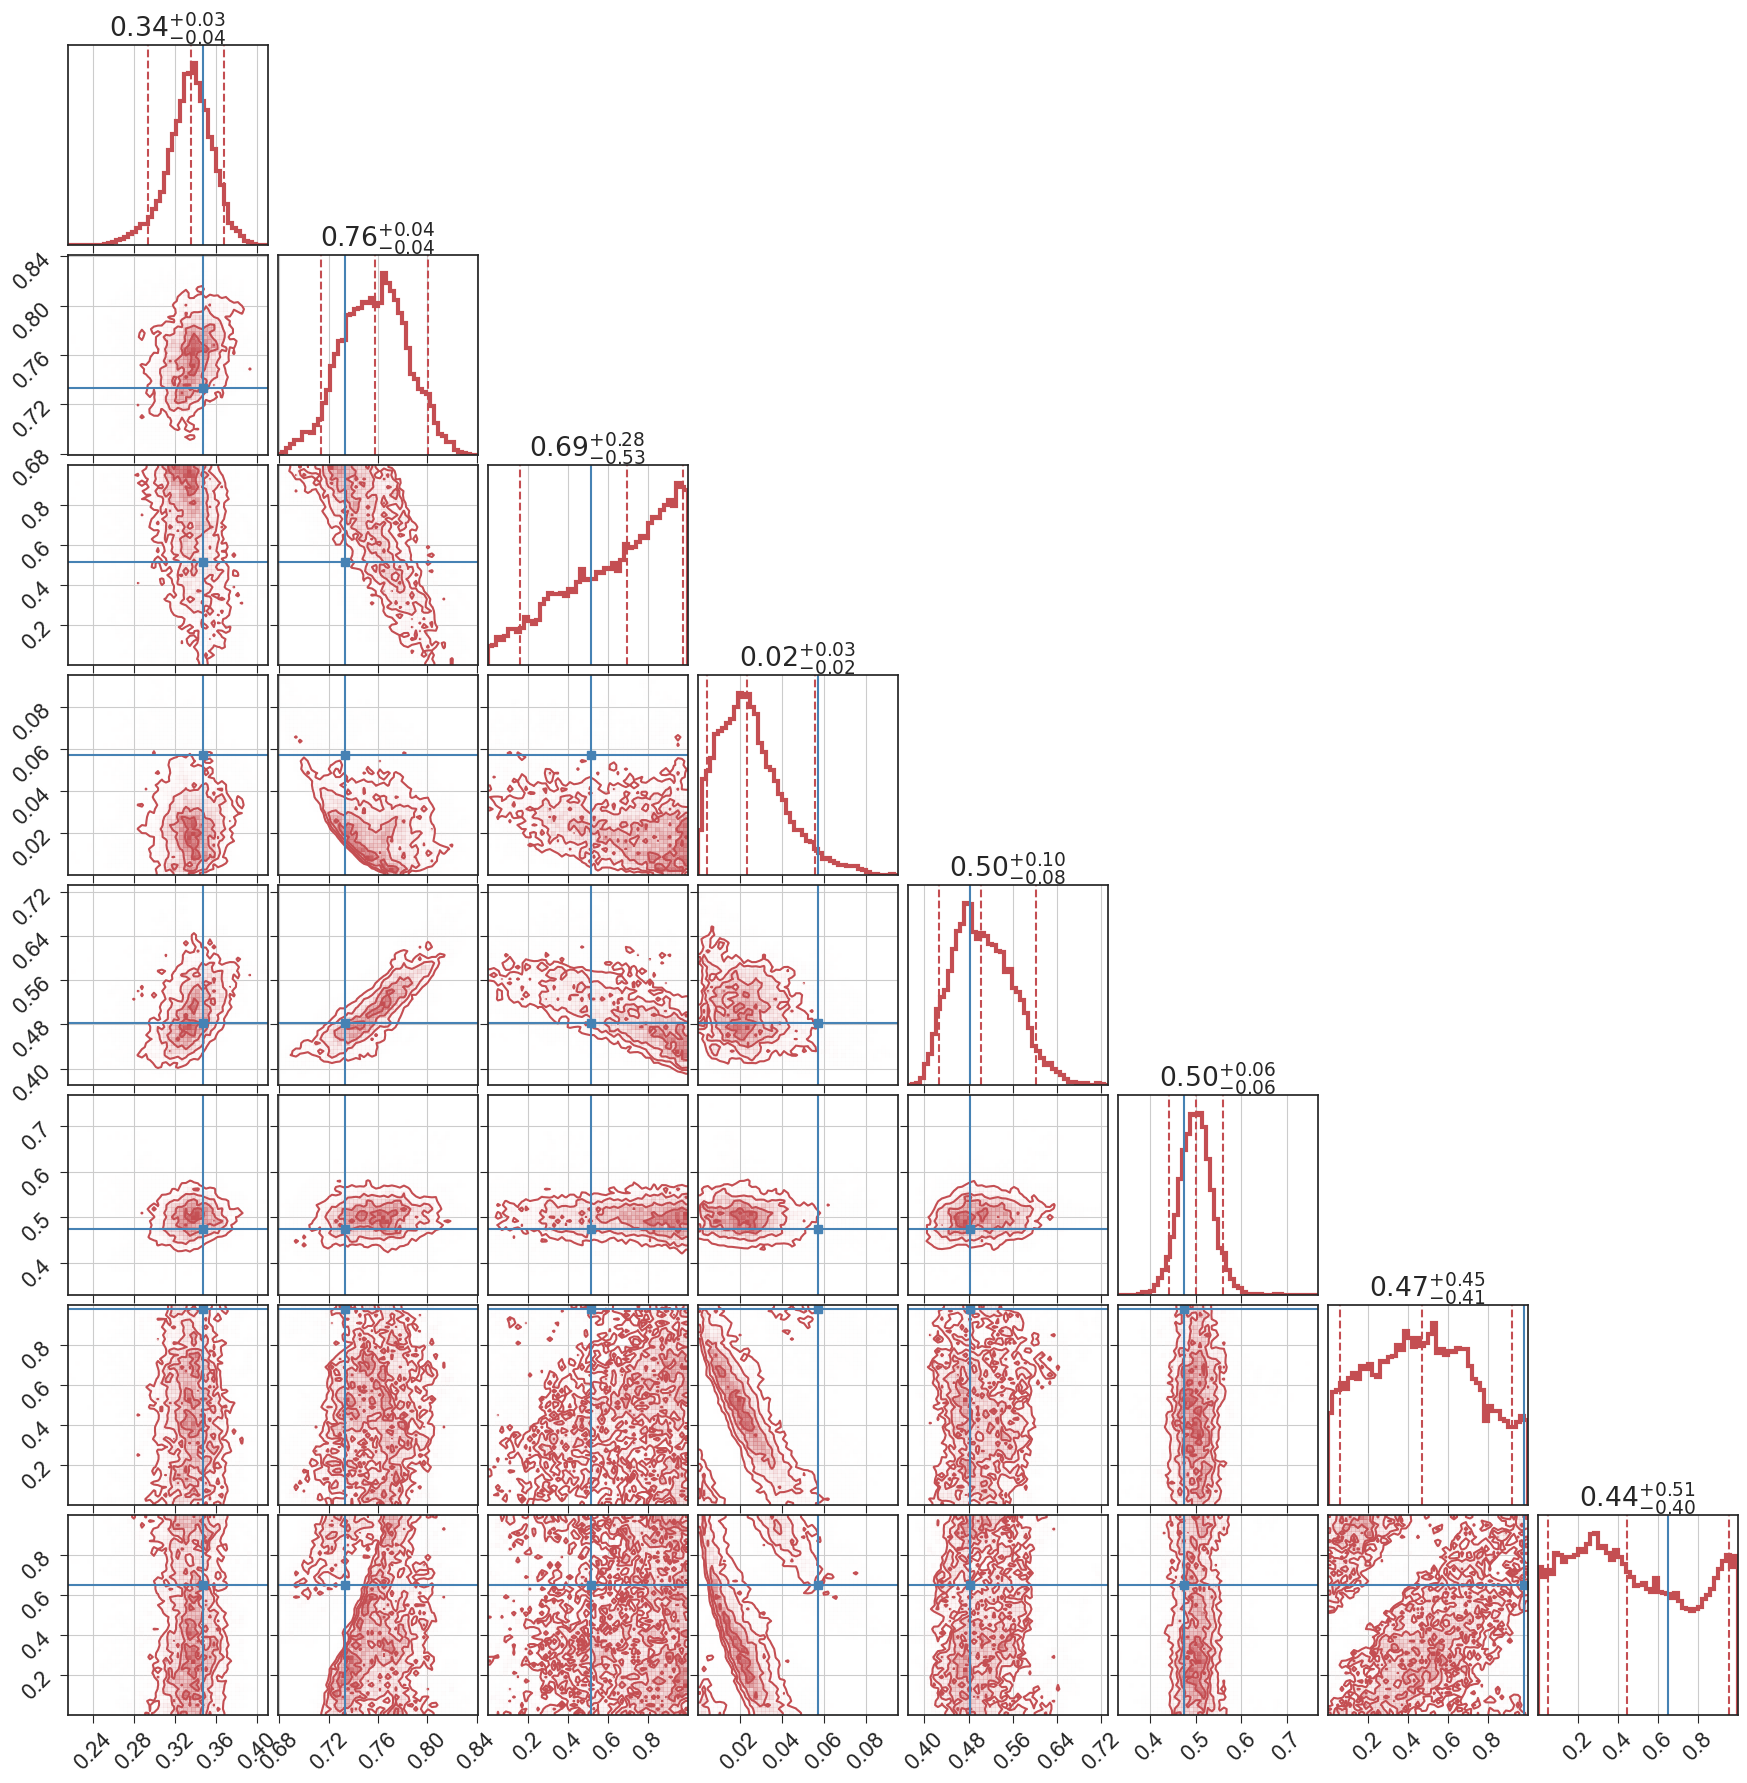

In [23]:
samples

import matplotlib.lines as mlines

start = 0
fig300 = corner.corner(samples[start:, :8], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[:8]) 

# corner.corner(ery_samples[:, :8], fig=fig300,bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[:8])

# line1 = mlines.Line2D([], [], color='C1', label='eryn')
# line2 = mlines.Line2D([], [], color='C2', label='my')

# Add the legend to the figure
# fig300.legend(handles=[line1, line2], loc='upper right', fontsize=20)


fig310 = corner.corner(samples[start:, 8:16], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[8:16]  ) 


# corner.corner(ery_samples[:, 8:16], fig=fig310, bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[8:16])

fig320 = corner.corner(samples[start:, 16:24], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[16:24]) 

# corner.corner(ery_samples[:, 16:24], fig=fig320, bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[16:24])

 
plt.show()